# Introduction to Least Squares

## Purpose

Understand least squares as finding the best approximate fit when an exact solution is not possible.

This notebook connects back to projections:

> least squares is closely related to projecting something onto a space of possible solutions.

We will keep the examples small and visual.

## Imports and helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_plot(xlim=(-1, 6), ylim=(-1, 6), figsize=(5.5, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax

## A simple fitting problem

Suppose we have some points:

$$
(1, 2), (2, 2.5), (3, 3.5), (4, 3.8)
$$

They do not lie perfectly on a straight line.

But we can still ask:

> what line fits these points reasonably well?

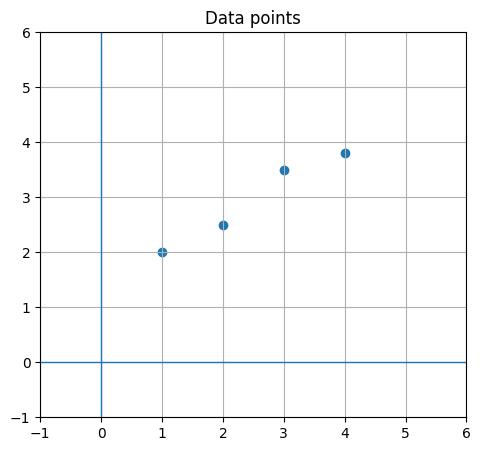

In [2]:
x = np.array([1, 2, 3, 4])
y = np.array([2.0, 2.5, 3.5, 3.8])

fig, ax = setup_plot()

ax.scatter(x, y)
ax.set_title("Data points")
plt.show()

## A line model

A straight line has the form:

$$
y = mx + c
$$

where:

- \(m\) is the slope
- \(c\) is the intercept

For a given \(m\) and \(c\), we can predict a y-value for every x-value.

In [3]:
m = 0.7
c = 1.2

predicted_y = m * x + c

print("actual y:", y)
print("predicted y:", predicted_y)

actual y: [2.  2.5 3.5 3.8]
predicted y: [1.9 2.6 3.3 4. ]


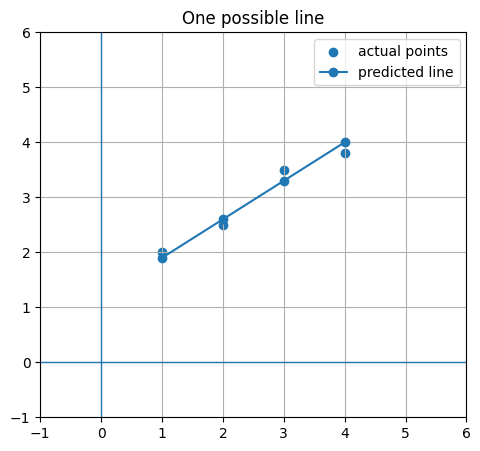

In [4]:
fig, ax = setup_plot()

ax.scatter(x, y, label="actual points")
ax.plot(x, predicted_y, marker="o", label="predicted line")

ax.legend()
ax.set_title("One possible line")
plt.show()

## Residuals

A residual is the difference between an actual value and a predicted value.

$$
\text{residual} = y - \hat{y}
$$

where \(\hat{y}\) is the predicted value.

In [5]:
residuals = y - predicted_y

print("residuals:", residuals)

residuals: [ 0.1 -0.1  0.2 -0.2]


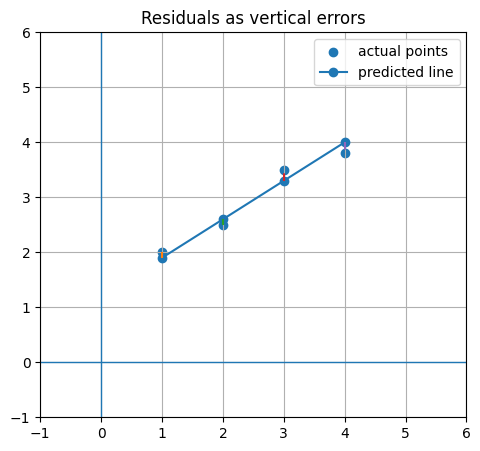

In [6]:
fig, ax = setup_plot()

ax.scatter(x, y, label="actual points")
ax.plot(x, predicted_y, marker="o", label="predicted line")

for xi, actual, predicted in zip(x, y, predicted_y):
    ax.plot([xi, xi], [predicted, actual], linestyle="--")

ax.legend()
ax.set_title("Residuals as vertical errors")
plt.show()

The dashed lines show the errors between the fitted line and the data points.

Least squares chooses the line that makes these errors small overall.

## Why square the residuals?

Residuals can be positive or negative.

If we simply add them, they can cancel out.

So least squares uses the sum of squared residuals:

$$
\sum_i (y_i - \hat{y}_i)^2
$$

In [7]:
sum_squared_residuals = np.sum(residuals ** 2)

print("sum of squared residuals:", sum_squared_residuals)

sum of squared residuals: 0.10000000000000009


Squaring does two useful things:

- negative and positive errors both become positive
- larger errors are penalised more heavily

## Let NumPy find the least-squares line

NumPy can fit a straight line using `np.polyfit`.

In [8]:
best_m, best_c = np.polyfit(x, y, deg=1)

print("best slope:", best_m)
print("best intercept:", best_c)

best slope: 0.6399999999999998
best intercept: 1.3500000000000008


In [9]:
best_predicted_y = best_m * x + best_c
best_residuals = y - best_predicted_y
best_ssr = np.sum(best_residuals ** 2)

print("best predicted y:", best_predicted_y)
print("best residuals:", best_residuals)
print("best sum of squared residuals:", best_ssr)

best predicted y: [1.99 2.63 3.27 3.91]
best residuals: [ 0.01 -0.13  0.23 -0.11]
best sum of squared residuals: 0.08199999999999993


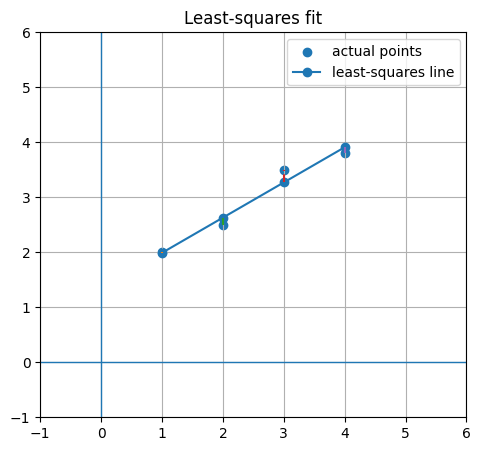

In [10]:
fig, ax = setup_plot()

ax.scatter(x, y, label="actual points")
ax.plot(x, best_predicted_y, marker="o", label="least-squares line")

for xi, actual, predicted in zip(x, y, best_predicted_y):
    ax.plot([xi, xi], [predicted, actual], linestyle="--")

ax.legend()
ax.set_title("Least-squares fit")
plt.show()

## Matrix view of the same problem

The line equation:

$$
y = mx + c
$$

can be written as a matrix problem.

For the x-values \(1, 2, 3, 4\), build a matrix:

$$
X =
\begin{bmatrix}
1 & 1 \\
2 & 1 \\
3 & 1 \\
4 & 1
\end{bmatrix}
$$

The first column contains the x-values.

The second column contains ones for the intercept.

In [11]:
X = np.column_stack([x, np.ones_like(x)])

print(X)

[[1 1]
 [2 1]
 [3 1]
 [4 1]]


The unknown parameters are:

$$
\beta =
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

Then the predictions are:

$$
X\beta
$$

In [12]:
beta = np.array([best_m, best_c])

predictions_from_matrix = X @ beta

print("X @ beta:", predictions_from_matrix)
print("best predicted y:", best_predicted_y)

X @ beta: [1.99 2.63 3.27 3.91]
best predicted y: [1.99 2.63 3.27 3.91]


## Solving with `np.linalg.lstsq`

NumPy can solve the least-squares problem directly:

$$
X \beta \approx y
$$

This means:

> find the best \(eta\) when \(X\beta = y\) cannot usually be satisfied exactly.

In [13]:
beta_lstsq, residual_sums, rank, singular_values = np.linalg.lstsq(X, y, rcond=None)

print("beta from lstsq:", beta_lstsq)
print("slope:", beta_lstsq[0])
print("intercept:", beta_lstsq[1])

beta from lstsq: [0.64 1.35]
slope: 0.6400000000000003
intercept: 1.3499999999999985


The result matches the line fitted earlier.

This is the least-squares solution.

## Connection back to projection

In the projection notebook, we split a vector into:

$$
\text{parallel component} + \text{perpendicular component}
$$

Least squares has a similar flavour.

It finds the prediction that lies in the space of possible model outputs, leaving a residual error that cannot be explained by the model.

That residual is the leftover part.

## Summary

- Least squares is used when an exact fit is not possible.
- A residual is the difference between actual and predicted values.
- Least squares minimises the sum of squared residuals.
- A line \(y = mx + c\) can be written as a matrix problem.
- `np.linalg.lstsq` solves least-squares problems directly.
- Least squares connects naturally to projection and perpendicular residuals.

## Next step

Possible next directions:

- solve small linear systems
- look at matrix inverses
- explore rank and dependent columns
- connect least squares to simple linear regression